<a href="https://colab.research.google.com/github/AbhiSatwika-cell/Metasurafce-designing/blob/main/Final7_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (490490, 2) (490490,)

RANDOM FOREST
MAE : 0.0006298750803389854
RMSE: 0.0014345794439325171
R2  : 0.9999427977400778

GRADIENT BOOSTING
MAE : 0.020995629834531578
RMSE: 0.03925039062887544
R2  : 0.95717947905089

NEURAL NETWORK
MAE : 0.003537015986585699
RMSE: 0.012650441065777788
R2  : 0.9955518920813161


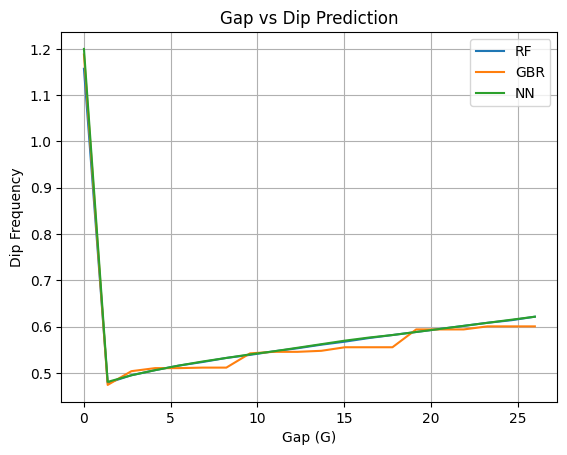

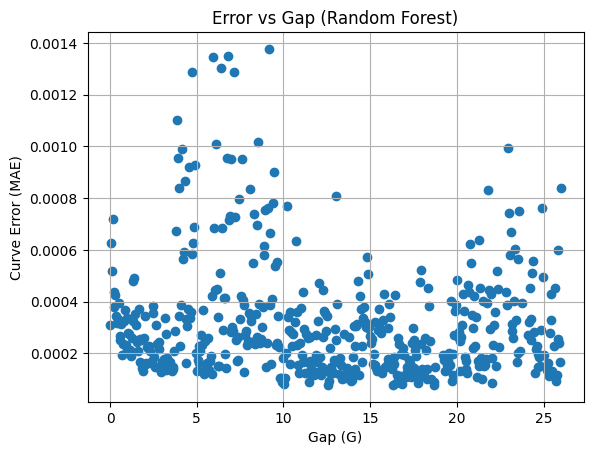

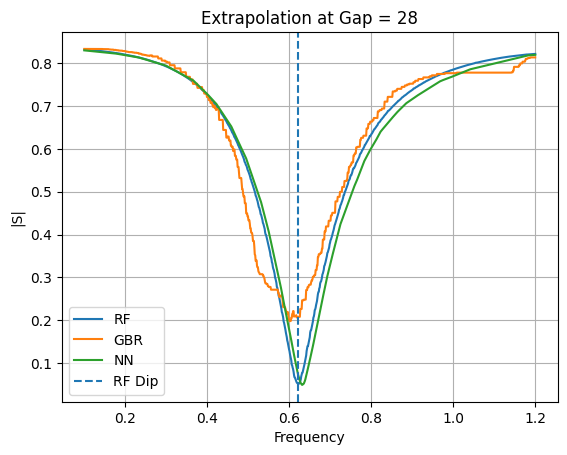

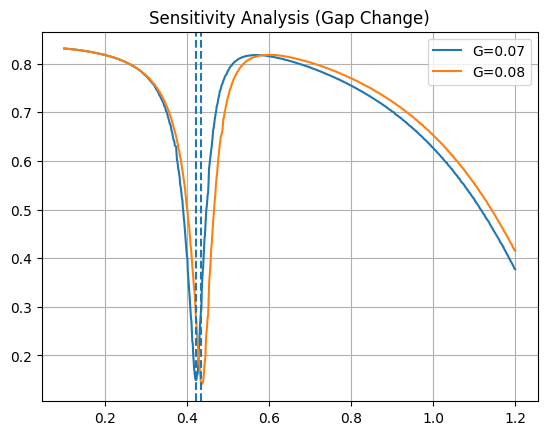


✅ ALL FILES READY FOR ORIGIN


In [ ]:
# ================================
# INSTALL (if needed)
# ================================
!pip install scikit-learn matplotlib pandas numpy

# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("revfinal_reformed.csv")

freq_cols = df.columns[7:].astype(float)

# ================================
# CREATE FUNCTIONAL DATASET
# ================================
X = []
y = []

for i in range(len(df)):
    gap = df.loc[i, 'G']
    curve = df.iloc[i, 7:].values

    for j, freq in enumerate(freq_cols):
        X.append([gap, freq])
        y.append(curve[j])

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape, y.shape)

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# SCALING
# ================================
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1)).ravel()

# ================================
# MODELS
# ================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor()
mlp = MLPRegressor(hidden_layer_sizes=(128,64), max_iter=500)

rf.fit(X_train, y_train)
gbr.fit(X_train, y_train)
mlp.fit(X_train, y_train)

# ================================
# METRICS FUNCTION
# ================================
def evaluate(model, name):
    pred = model.predict(X_test)
    pred = y_scaler.inverse_transform(pred.reshape(-1,1)).ravel()

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

# ================================
# EVALUATION
# ================================
evaluate(rf, "RANDOM FOREST")
evaluate(gbr, "GRADIENT BOOSTING")
evaluate(mlp, "NEURAL NETWORK")

# ================================
# EXPORT: ACTUAL vs PREDICTED (RF)
# ================================
rf_pred = rf.predict(X_test)
rf_pred = y_scaler.inverse_transform(rf_pred.reshape(-1,1)).ravel()

df_pred = pd.DataFrame({
    "Actual": y_test,
    "Predicted_RF": rf_pred
})
df_pred.to_csv("actual_vs_predicted.csv", index=False)

# ================================
# FUNCTION: GENERATE CURVE FROM GAP
# ================================
def predict_curve(model, gap):
    freq_fixed = freq_cols

    X_new = np.array([[gap, f] for f in freq_fixed])
    X_new = x_scaler.transform(X_new)

    pred = model.predict(X_new)
    pred = y_scaler.inverse_transform(pred.reshape(-1,1)).ravel()

    return pred

# ================================
# FUNCTION: GET DIP
# ================================
def get_dip(curve):
    return freq_cols[np.argmin(curve)]

# ================================
# 1️⃣ GAP SWEEP ANALYSIS
# ================================
gaps = np.linspace(min(df['G']), max(df['G']), 20)

rf_dips = []
gbr_dips = []
mlp_dips = []

for g in gaps:
    rf_curve = predict_curve(rf, g)
    gbr_curve = predict_curve(gbr, g)
    mlp_curve = predict_curve(mlp, g)

    rf_dips.append(get_dip(rf_curve))
    gbr_dips.append(get_dip(gbr_curve))
    mlp_dips.append(get_dip(mlp_curve))

# Plot
plt.figure()
plt.plot(gaps, rf_dips, label="RF")
plt.plot(gaps, gbr_dips, label="GBR")
plt.plot(gaps, mlp_dips, label="NN")
plt.xlabel("Gap (G)")
plt.ylabel("Dip Frequency")
plt.title("Gap vs Dip Prediction")
plt.legend()
plt.grid()
plt.show()

# EXPORT
df_gap = pd.DataFrame({
    "Gap": gaps,
    "RF_Dip": rf_dips,
    "GBR_Dip": gbr_dips,
    "MLP_Dip": mlp_dips
})
df_gap.to_csv("gap_vs_dip.csv", index=False)

# ================================
# 2️⃣ ERROR vs GAP
# ================================
rf_error = []
g_list = []

for i in range(len(df)):
    g = df.loc[i, 'G']
    actual_curve = df.iloc[i, 7:].values

    pred_curve = predict_curve(rf, g)
    error = mean_absolute_error(actual_curve, pred_curve)

    g_list.append(g)
    rf_error.append(error)

plt.figure()
plt.scatter(g_list, rf_error)
plt.xlabel("Gap (G)")
plt.ylabel("Curve Error (MAE)")
plt.title("Error vs Gap (Random Forest)")
plt.grid()
plt.show()

# EXPORT
df_error = pd.DataFrame({
    "Gap": g_list,
    "RF_Error": rf_error
})
df_error.to_csv("error_vs_gap.csv", index=False)

# ================================
# 3️⃣ EXTRAPOLATION TEST
# ================================
test_gap = 28

rf_curve = predict_curve(rf, test_gap)
gbr_curve = predict_curve(gbr, test_gap)
mlp_curve = predict_curve(mlp, test_gap)

plt.figure()
plt.plot(freq_cols, rf_curve, label="RF")
plt.plot(freq_cols, gbr_curve, label="GBR")
plt.plot(freq_cols, mlp_curve, label="NN")
plt.axvline(get_dip(rf_curve), linestyle='--', label="RF Dip")
plt.xlabel("Frequency")
plt.ylabel("|S|")
plt.title(f"Extrapolation at Gap = {test_gap}")
plt.legend()
plt.grid()
plt.show()

# EXPORT
df_extra = pd.DataFrame({
    "Frequency": freq_cols,
    "RF": rf_curve,
    "GBR": gbr_curve,
    "MLP": mlp_curve
})
df_extra.to_csv("extrapolation.csv", index=False)

# ================================
# 4️⃣ SENSITIVITY ANALYSIS
# ================================
g = 0.07
delta = 0.01

curve1 = predict_curve(rf, g)
curve2 = predict_curve(rf, g + delta)

plt.figure()
plt.plot(freq_cols, curve1, label=f"G={g}")
plt.plot(freq_cols, curve2, label=f"G={g+delta}")
plt.axvline(get_dip(curve1), linestyle='--')
plt.axvline(get_dip(curve2), linestyle='--')
plt.title("Sensitivity Analysis (Gap Change)")
plt.legend()
plt.grid()
plt.show()

# EXPORT
df_sens = pd.DataFrame({
    "Frequency": freq_cols,
    "G1": curve1,
    "G2": curve2
})
df_sens.to_csv("sensitivity.csv", index=False)

print("\n✅ ALL FILES READY FOR ORIGIN")

 Gaussian Process Regression (GPR)

In [ ]:
# ================================
# INSTALL IN COLAB
# ================================
!pip install gpytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 5.1 MB/s eta 0:00:00


Training Sparse GPR...
Epoch 10/50  Loss: -1.3539
Epoch 20/50  Loss: -1.3836
Epoch 30/50  Loss: -0.8693
Epoch 40/50  Loss: -1.1331
Epoch 50/50  Loss: -1.1902
Enter gap: 28.0
Correct Dip Frequency: 0.6269


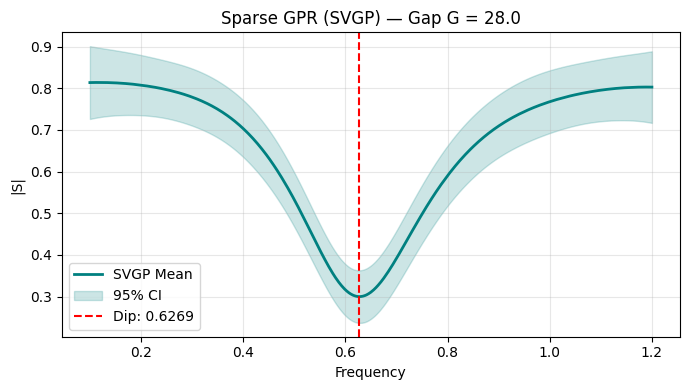

In [ ]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# ================================
# SPARSE GPR (SVGP)
# ================================
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True
        )
        super().__init__(variational_strategy)

        self.mean_module  = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=1.5)
        )

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(
            self.mean_module(x),
            self.covar_module(x)
        )


# ================================
# INITIALIZATION
# ================================
N_INDUCING = 300
idx_ind = np.random.choice(len(X_train), N_INDUCING, replace=False)
inducing_pts = torch.FloatTensor(X_train[idx_ind])

svgp = SVGPModel(inducing_pts)
likelihood = gpytorch.likelihoods.GaussianLikelihood()


# ================================
# TRAINING
# ================================
X_t = torch.FloatTensor(X_train)
y_t = torch.FloatTensor(y_train)

train_ds = torch.utils.data.TensorDataset(X_t, y_t)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=512, shuffle=True)

svgp.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': svgp.parameters()},
    {'params': likelihood.parameters()}
], lr=0.01)

mll = gpytorch.mlls.VariationalELBO(likelihood, svgp, num_data=len(X_train))

print("Training Sparse GPR...")

for epoch in range(50):
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = -mll(svgp(xb), yb)
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50  Loss: {loss.item():.4f}")


# ================================
# PREDICTION FUNCTION (FIXED)
# ================================
def predict_curve_svgp(gap):
    svgp.eval()
    likelihood.eval()

    # Create input grid
    freqs = freq_cols.astype(float)
    X_new = np.array([[gap, f] for f in freqs])
    X_new_sc = x_scaler.transform(X_new)

    X_new_t = torch.FloatTensor(X_new_sc)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(svgp(X_new_t))
        mu    = pred.mean.numpy()
        sigma = pred.variance.sqrt().numpy()

    # Inverse scaling
    mu = y_scaler.inverse_transform(mu.reshape(-1, 1)).ravel()
    sigma = sigma * y_scaler.scale_[0]

    # 🔥 IMPORTANT FIX: SORT EVERYTHING
    sort_idx = np.argsort(freqs)

    freqs_sorted = freqs[sort_idx]
    mu_sorted    = mu[sort_idx]
    sigma_sorted = sigma[sort_idx]

    return freqs_sorted, mu_sorted, sigma_sorted


# ================================
# USER INPUT + PLOT
# ================================
user_gap = float(input("Enter gap: "))

freqs, mu, sigma = predict_curve_svgp(user_gap)

# ✅ Correct dip calculation
dip = freqs[np.argmin(mu)]

print(f"Correct Dip Frequency: {dip:.4f}")


# ================================
# PLOT
# ================================
plt.figure(figsize=(7, 4))

plt.plot(freqs, mu, color='teal', linewidth=2, label='SVGP Mean')

plt.fill_between(freqs,
                 mu - 2*sigma,
                 mu + 2*sigma,
                 alpha=0.2,
                 color='teal',
                 label='95% CI')

plt.axvline(dip,
            linestyle='--',
            color='red',
            linewidth=1.5,
            label=f'Dip: {dip:.4f}')

plt.xlabel("Frequency")
plt.ylabel("|S|")
plt.title(f"Sparse GPR (SVGP) — Gap G = {user_gap}")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ================================
# SVGP Evaluation
# ================================
svgp.eval()
likelihood.eval()

X_test_t = torch.FloatTensor(X_test)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(svgp(X_test_t))
    mu = pred.mean.numpy()
    sigma = pred.variance.sqrt().numpy()

# Inverse transform
y_pred = y_scaler.inverse_transform(mu.reshape(-1,1)).ravel()
y_true = y_test

# ================================
# Metrics
# ================================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("\nSVGP PERFORMANCE")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")
print(f"Accuracy: {r2*100:.4f}%")


SVGP PERFORMANCE
MAE  : 0.004614
RMSE : 0.014358
R²   : 0.994270
Accuracy: 99.4270%


In [ ]:
# ================================
# Uncertainty Metric (NLL)
# ================================
var = sigma**2 + 1e-6  # avoid log(0)

nll = np.mean(0.5 * np.log(2 * np.pi * var) + ((y_true - y_pred)**2) / (2 * var))

print(f"NLL  : {nll:.6f}")

NLL  : -1.462007


In [ ]:
# ================================
# EXPORT DATA FOR ORIGIN
# ================================
import pandas as pd
import numpy as np
current_user_gap = 28
freq_values, mean_values, sigma_values = predict_curve_svgp(current_user_gap)

# Prepare data for DataFrame
freq_np = freq_values
mean_np = mean_values
lower_np = mean_values - 2 * sigma_values
upper_np = mean_values + 2 * sigma_values

# Create DataFrame
df_export = pd.DataFrame({
    "Frequency": freq_np,
    "SVGP_Mean": mean_np,
    "Lower_95CI": lower_np,
    "Upper_95CI": upper_np
})

# Save as CSV
file_name = f"svgp_curve_gap_{current_user_gap}.csv"
df_export.to_csv(file_name, index=False)

print(f"✅ Saved: {file_name}")

✅ Saved: svgp_curve_gap_28.csv


XGBoost + LightGBM

In [ ]:
# pip install xgboost lightgbm

import xgboost as xgb
import lightgbm as lgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', random_state=42, verbosity=0
)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=-1
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test_scaled)],
              verbose=False)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test_scaled)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

evaluate(xgb_model, "XGBOOST")
evaluate(lgb_model, "LIGHTGBM")


XGBOOST
MAE : 0.06084281571646325
RMSE: 0.09643997585023609
R2  : 0.7414895129723242


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



LIGHTGBM
MAE : 0.0029833908850710497
RMSE: 0.009916805467777005
R2  : 0.9972665724458207


In [ ]:
# pip install torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class MetasurfaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

# Prepare data
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256,
    shuffle=True
)

# Train
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MetasurfaceNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(100):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

# Evaluate
model.eval()
with torch.no_grad():
    pred = model(X_test_t.to(device)).cpu().numpy().ravel()
    pred = y_scaler.inverse_transform(pred.reshape(-1,1)).ravel()

print("\nDEEP NEURAL NETWORK")
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))


KeyboardInterrupt: 

1D Convolutional Neural Network — treats the spectrum as a sequence

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ================================
# 1D CNN — full curve prediction
# ================================
# Train one model per gap: input = gap scalar, output = full |S(f)| vector
X_curves = df['G'].values.reshape(-1, 1)   # (N, 1)
y_curves  = df.iloc[:, 7:].values           # (N, F)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_curves, y_curves, test_size=0.2, random_state=42
)

x_sc2 = StandardScaler(); y_sc2 = StandardScaler()
X_c_train = x_sc2.fit_transform(X_c_train)
X_c_test  = x_sc2.transform(X_c_test)
y_c_train = y_sc2.fit_transform(y_c_train)
y_c_test  = y_sc2.transform(y_c_test)

Xt = torch.FloatTensor(X_c_train)
yt = torch.FloatTensor(y_c_train)

F_out = y_curves.shape[1]  # number of frequency points

class CNN1D(nn.Module):
    def __init__(self, f_out):
        super().__init__()
        self.fc_in  = nn.Linear(1, 64)
        self.expand = nn.Linear(64, 128 * 8)
        self.conv   = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),  nn.ReLU(),
            nn.Conv1d(32, 1,  kernel_size=3, padding=1)
        )
        self.fc_out = nn.Linear(8, f_out)

    def forward(self, x):
        x = torch.relu(self.fc_in(x))
        x = torch.relu(self.expand(x)).view(-1, 128, 8)
        x = self.conv(x).squeeze(1)
        return self.fc_out(x)

cnn = CNN1D(F_out)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(Xt, yt), batch_size=32, shuffle=True)

for epoch in range(200):
    cnn.train()
    for xb, yb in loader:
        loss = nn.MSELoss()(cnn(xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.5f}")

# Evaluate
cnn.eval()
with torch.no_grad():
    pred_cnn = cnn(torch.FloatTensor(X_c_test)).numpy()
pred_cnn = y_sc2.inverse_transform(pred_cnn)
y_c_test_orig = y_sc2.inverse_transform(y_c_test)
print(f"\nCNN — Curve R²: {r2_score(y_c_test_orig.ravel(), pred_cnn.ravel()):.4f}")
print(f"CNN — Curve MAE: {mean_absolute_error(y_c_test_orig.ravel(), pred_cnn.ravel()):.4f}")

 Residual MLP (ResNet-style)

In [ ]:


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# ================================
# CHECK YOUR DATA SIZE FIRST
# ================================
print(f"X_train shape : {X_train.shape}")
print(f"Total samples : {len(X_train)}")
print(f"Recommended batch size: {min(1024, len(X_train)//50)}")

In [ ]:
# ================================
# LIGHTWEIGHT RESIDUAL MLP
# ================================

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Linear(dim, dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class ResMLPFast(nn.Module):
    def __init__(self, in_dim=2, hidden=64, n_blocks=2):

        super().__init__()
        self.stem   = nn.Linear(in_dim, hidden)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden)
                                       for _ in range(n_blocks)])
        self.head   = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.head(self.blocks(torch.relu(self.stem(x)))).squeeze(-1)


# ================================
# SUBSAMPLE IF DATASET IS VERY LARGE
# ================================
MAX_TRAIN = 80_000   # cap at 80k rows — enough for good accuracy

if len(X_train) > MAX_TRAIN:
    idx = np.random.choice(len(X_train), MAX_TRAIN, replace=False)
    X_tr_fast = X_train[idx]
    y_tr_fast = y_train[idx]
    print(f"Subsampled: {len(X_train):,} → {MAX_TRAIN:,} rows")
else:
    X_tr_fast = X_train
    y_tr_fast = y_train
    print(f"Using full dataset: {len(X_train):,} rows")

# ================================
# FAST TRAINING SETTINGS
# ================================
EPOCHS    = 80      # was 300 — 80 is enough with cosine LR
BATCH     = 2048    # was 256 — larger batch = fewer steps per epoch
LR        = 3e-3    # higher LR compensates for fewer epochs

Xt = torch.FloatTensor(X_tr_fast)
yt = torch.FloatTensor(y_tr_fast)
Xte = torch.FloatTensor(X_test)

loader = DataLoader(
    TensorDataset(Xt, yt),
    batch_size=BATCH,
    shuffle=True,
    pin_memory=False   # set True only if using GPU
)

resnet = ResMLPFast(hidden=64, n_blocks=2)

# Check if GPU is available in Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
resnet = resnet.to(device)

opt = torch.optim.AdamW(resnet.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.MSELoss()

# ================================
# TRAINING LOOP WITH TIME ESTIMATE
# ================================
import time

print(f"\nTraining Residual MLP — {EPOCHS} epochs, batch={BATCH}")
print(f"Steps per epoch: {len(loader)}")
print("-" * 40)

start = time.time()

for epoch in range(EPOCHS):
    resnet.train()
    epoch_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = resnet(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    scheduler.step()

    # Print every 10 epochs with time estimate
    if (epoch + 1) % 10 == 0:
        elapsed   = time.time() - start
        per_epoch = elapsed / (epoch + 1)
        remaining = per_epoch * (EPOCHS - epoch - 1)
        print(f"  Epoch {epoch+1:>3}/{EPOCHS} | "
              f"Loss: {epoch_loss/len(loader):.5f} | "
              f"Elapsed: {elapsed/60:.1f}m | "
              f"ETA: {remaining/60:.1f}m")

total_time = time.time() - start
print(f"\nDone in {total_time/60:.1f} minutes")

# ================================
# EVALUATE
# ================================
resnet.eval()
with torch.no_grad():
    pred_sc = resnet(Xte.to(device)).cpu().numpy()

pred_res = y_scaler.inverse_transform(pred_sc.reshape(-1, 1)).ravel()
print(f"\nRESIDUAL MLP (fast)")
print(f"  MAE : {mean_absolute_error(y_test, pred_res):.5f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, pred_res)):.5f}")
print(f"  R²  : {r2_score(y_test, pred_res):.5f}")

# ================================
# WRAPPER FOR CURVE PREDICTION
# ================================
class TorchModelWrapper:
    def __init__(self, model, device):
        self.model  = model
        self.device = device

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            out = self.model(
                torch.FloatTensor(X).to(self.device)
            ).cpu().numpy()
        return out.ravel()

resnet_sklearn = TorchModelWrapper(resnet, device)
print("\n✅ resnet_sklearn ready for plot_curve_for_gap()")

In [ ]:
!pip install pykan

In [ ]:
# ================================
# 5️⃣ USER INPUT GAP — ALL MODELS (SEPARATE GRAPHS + EXPORT)
# ================================

user_gap = float(input("Enter Gap value (G): "))

# ---- Helper: predict from torch wrapper ----
def predict_curve(model, gap):
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    pred = model.predict(X_new_sc)
    return y_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()

def predict_curve_torch(wrapper, gap):
    """For TorchModelWrapper objects"""
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    return wrapper.predict(X_new_sc)

def predict_curve_gpr(gap):
    """GPR — also returns uncertainty"""
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    mu, sigma = gpr.predict(X_new_sc, return_std=True)
    mu    = y_scaler.inverse_transform(mu.reshape(-1, 1)).ravel()
    sigma = sigma * y_scaler.scale_[0]
    return mu, sigma

def get_dip(curve):
    return freq_cols.astype(float)[np.argmin(curve)]

def plot_and_export(freq, curve, dip, title, filename,
                    sigma=None, color='steelblue'):
    """
    Plots a single model curve with dip marker and exports CSV.
    sigma: uncertainty array (GPR only), else None
    """
    plt.figure(figsize=(7, 4))
    plt.plot(freq, curve, color=color, linewidth=2, label='Predicted |S|')

    if sigma is not None:
        plt.fill_between(freq,
                         curve - 2 * sigma,
                         curve + 2 * sigma,
                         alpha=0.2, color=color, label='95% CI')

    plt.axvline(dip, linestyle='--', color='red',
                linewidth=1.5, label=f'Dip: {dip:.4f}')
    plt.xlabel("Frequency")
    plt.ylabel("|S|")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Export
    out = {"Frequency": freq, "Predicted_S": curve}
    if sigma is not None:
        out["Lower_95CI"] = curve - 2 * sigma
        out["Upper_95CI"] = curve + 2 * sigma
    pd.DataFrame(out).to_csv(filename, index=False)
    print(f"  ✅ Saved: {filename}")

freqs = freq_cols.astype(float)

# ================================
# EXISTING MODELS
# ================================

# --- Random Forest ---
rf_curve = predict_curve(rf, user_gap)
rf_dip   = get_dip(rf_curve)
print(f"\nRF  Dip: {rf_dip:.4f}")
plot_and_export(freqs, rf_curve, rf_dip,
                f"Random Forest (G = {user_gap})",
                f"RF_gap_{user_gap}.csv",
                color='steelblue')

# --- Gradient Boosting ---
gbr_curve = predict_curve(gbr, user_gap)
gbr_dip   = get_dip(gbr_curve)
print(f"GBR Dip: {gbr_dip:.4f}")
plot_and_export(freqs, gbr_curve, gbr_dip,
                f"Gradient Boosting (G = {user_gap})",
                f"GBR_gap_{user_gap}.csv",
                color='darkorange')

# --- MLP (sklearn) ---
mlp_curve = predict_curve(mlp, user_gap)
mlp_dip   = get_dip(mlp_curve)
print(f"MLP Dip: {mlp_dip:.4f}")
plot_and_export(freqs, mlp_curve, mlp_dip,
                f"MLP Neural Net (G = {user_gap})",
                f"MLP_gap_{user_gap}.csv",
                color='seagreen')

# ================================
# NEW BOOSTING MODELS
# ================================

# --- XGBoost ---
xgb_curve = predict_curve(xgb_model, user_gap)
xgb_dip   = get_dip(xgb_curve)
print(f"XGB Dip: {xgb_dip:.4f}")
plot_and_export(freqs, xgb_curve, xgb_dip,
                f"XGBoost (G = {user_gap})",
                f"XGB_gap_{user_gap}.csv",
                color='crimson')

# --- LightGBM ---
lgb_curve = predict_curve(lgb_model, user_gap)
lgb_dip   = get_dip(lgb_curve)
print(f"LGB Dip: {lgb_dip:.4f}")
plot_and_export(freqs, lgb_curve, lgb_dip,
                f"LightGBM (G = {user_gap})",
                f"LGB_gap_{user_gap}.csv",
                color='purple')

# ================================
# GPR — with uncertainty bands
# ================================
gpr_mu, gpr_sigma = predict_curve_svgp(user_gap)
gpr_dip = get_dip(gpr_mu)
print(f"GPR Dip: {gpr_dip:.4f}")
plot_and_export(freqs, gpr_mu, gpr_dip,
                f"Gaussian Process Regression (G = {user_gap})",
                f"GPR_gap_{user_gap}.csv",
                sigma=gpr_sigma,
                color='teal')

# ================================
# DEEP LEARNING MODELS
# ================================
# --- Residual MLP ---
res_curve = predict_curve_torch(resnet_sklearn, user_gap)
res_dip   = get_dip(res_curve)
print(f"ResNet MLP Dip: {res_dip:.4f}")
plot_and_export(freqs, res_curve, res_dip,
                f"Residual MLP (G = {user_gap})",
                f"ResNet_gap_{user_gap}.csv",
                color='chocolate')




# ================================
# SUMMARY TABLE
# ================================
print("\n" + "="*45)
print(f"{'Model':<22} {'Dip Frequency':>20}")
print("="*45)
for name, dip in [
    ("Random Forest",    rf_dip),
    ("Gradient Boost",   gbr_dip),
    ("MLP",              mlp_dip),
    ("XGBoost",          xgb_dip),
    ("LightGBM",         lgb_dip),
    ("GPR",              gpr_dip),
    ("Residual MLP",     res_dip),


]:
    print(f"  {name:<20} {dip:>20.4f}")
print("="*45)

# Export unified summary
pd.DataFrame({
    "Model": ["RF","GBR","MLP","XGBoost","LightGBM","SVGP","ResidualMLP"],
    "Dip_Frequency": [rf_dip, gbr_dip, mlp_dip, xgb_dip, lgb_dip, gpr_dip,res_dip],
    "Gap": user_gap
}).to_csv(f"all_dips_gap_{user_gap}.csv", index=False)

print(f"\n✅ All graphs shown & all files exported for Gap G = {user_gap}!")

In [ ]:
# ================================
# 5️⃣ USER INPUT GAP — ALL MODELS (SEPARATE GRAPHS + EXPORT)
# ================================

user_gap = float(input("Enter Gap value (G): "))

# ---- Helper: predict from torch wrapper ----
def predict_curve(model, gap):
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    pred = model.predict(X_new_sc)
    return y_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()

def predict_curve_torch(wrapper, gap):
    """For TorchModelWrapper objects"""
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    return wrapper.predict(X_new_sc)

def predict_curve_gpr(gap):
    """GPR — also returns uncertainty"""
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new_sc = x_scaler.transform(X_new)
    mu, sigma = gpr.predict(X_new_sc, return_std=True)
    mu    = y_scaler.inverse_transform(mu.reshape(-1, 1)).ravel()
    sigma = sigma * y_scaler.scale_[0]
    return mu, sigma

def get_dip(curve):
    return freq_cols.astype(float)[np.argmin(curve)]

def plot_and_export(freq, curve, dip, title, filename,
                    sigma=None, color='steelblue'):
    """
    Plots a single model curve with dip marker and exports CSV.
    sigma: uncertainty array (GPR only), else None
    """
    plt.figure(figsize=(7, 4))
    plt.plot(freq, curve, color=color, linewidth=2, label='Predicted |S|')

    if sigma is not None:
        plt.fill_between(freq,
                         curve - 2 * sigma,
                         curve + 2 * sigma,
                         alpha=0.2, color=color, label='95% CI')

    plt.axvline(dip, linestyle='--', color='red',
                linewidth=1.5, label=f'Dip: {dip:.4f}')
    plt.xlabel("Frequency")
    plt.ylabel("|S|")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Export
    out = {"Frequency": freq, "Predicted_S": curve}
    if sigma is not None:
        out["Lower_95CI"] = curve - 2 * sigma
        out["Upper_95CI"] = curve + 2 * sigma
    pd.DataFrame(out).to_csv(filename, index=False)
    print(f"  ✅ Saved: {filename}")

freqs = freq_cols.astype(float)

# ================================
# EXISTING MODELS
# ================================

# --- Random Forest ---
rf_curve = predict_curve(rf, user_gap)
rf_dip   = get_dip(rf_curve)
print(f"\nRF  Dip: {rf_dip:.4f}")
plot_and_export(freqs, rf_curve, rf_dip,
                f"Random Forest (G = {user_gap})",
                f"RF_gap_{user_gap}.csv",
                color='steelblue')

# --- Gradient Boosting ---
gbr_curve = predict_curve(gbr, user_gap)
gbr_dip   = get_dip(gbr_curve)
print(f"GBR Dip: {gbr_dip:.4f}")
plot_and_export(freqs, gbr_curve, gbr_dip,
                f"Gradient Boosting (G = {user_gap})",
                f"GBR_gap_{user_gap}.csv",
                color='darkorange')

# --- MLP (sklearn) ---
mlp_curve = predict_curve(mlp, user_gap)
mlp_dip   = get_dip(mlp_curve)
print(f"MLP Dip: {mlp_dip:.4f}")
plot_and_export(freqs, mlp_curve, mlp_dip,
                f"MLP Neural Net (G = {user_gap})",
                f"MLP_gap_{user_gap}.csv",
                color='seagreen')

# ================================
# NEW BOOSTING MODELS
# ================================

# --- XGBoost ---
xgb_curve = predict_curve(xgb_model, user_gap)
xgb_dip   = get_dip(xgb_curve)
print(f"XGB Dip: {xgb_dip:.4f}")
plot_and_export(freqs, xgb_curve, xgb_dip,
                f"XGBoost (G = {user_gap})",
                f"XGB_gap_{user_gap}.csv",
                color='crimson')

# --- LightGBM ---
lgb_curve = predict_curve(lgb_model, user_gap)
lgb_dip   = get_dip(lgb_curve)
print(f"LGB Dip: {lgb_dip:.4f}")
plot_and_export(freqs, lgb_curve, lgb_dip,
                f"LightGBM (G = {user_gap})",
                f"LGB_gap_{user_gap}.csv",
                color='purple')

# ================================
# GPR — with uncertainty bands
# ================================
gpr_mu, gpr_sigma = predict_curve_svgp(user_gap)
gpr_dip = get_dip(gpr_mu)
print(f"GPR Dip: {gpr_dip:.4f}")
plot_and_export(freqs, gpr_mu, gpr_dip,
                f"Gaussian Process Regression (G = {user_gap})",
                f"GPR_gap_{user_gap}.csv",
                sigma=gpr_sigma,
                color='teal')

# ================================
# DEEP LEARNING MODELS
# ================================
# --- Residual MLP ---
res_curve = predict_curve_torch(resnet_sklearn, user_gap)
res_dip   = get_dip(res_curve)
print(f"ResNet MLP Dip: {res_dip:.4f}")
plot_and_export(freqs, res_curve, res_dip,
                f"Residual MLP (G = {user_gap})",
                f"ResNet_gap_{user_gap}.csv",
                color='chocolate')




# ================================
# SUMMARY TABLE
# ================================
print("\n" + "="*45)
print(f"{'Model':<22} {'Dip Frequency':>20}")
print("="*45)
for name, dip in [
    ("Random Forest",    rf_dip),
    ("Gradient Boost",   gbr_dip),
    ("MLP",              mlp_dip),
    ("XGBoost",          xgb_dip),
    ("LightGBM",         lgb_dip),
    ("GPR",              gpr_dip),
    ("Residual MLP",     res_dip),


]:
    print(f"  {name:<20} {dip:>20.4f}")
print("="*45)

# Export unified summary
pd.DataFrame({
    "Model": ["RF","GBR","MLP","XGBoost","LightGBM","SVGP","ResidualMLP"],
    "Dip_Frequency": [rf_dip, gbr_dip, mlp_dip, xgb_dip, lgb_dip, gpr_dip,res_dip],
    "Gap": user_gap
}).to_csv(f"all_dips_gap_{user_gap}.csv", index=False)

print(f"\n✅ All graphs shown & all files exported for Gap G = {user_gap}!")

In [ ]:
# ================================
# IMPROVED get_dip — finds the TRUE resonance dip
# not just the global minimum
# ================================
from scipy.signal import find_peaks

def get_dip_smart(curve, freqs):
    """
    Finds the resonance dip properly using peak detection on
    the inverted curve. Falls back to argmin if no peak found.

    Works correctly even when curve edges are lower than the dip.
    """
    curve  = np.array(curve, dtype=float)
    freqs  = np.array(freqs, dtype=float)

    # Invert curve — dips become peaks
    inv = -curve

    # Find peaks on inverted curve
    # prominence ensures we find real dips, not noise
    peaks, props = find_peaks(
        inv,
        prominence=0.03,      # dip must be at least 3% deep
        width=2,              # dip must be at least 2 points wide
        distance=5            # minimum spacing between dips
    )

    if len(peaks) == 0:
        # Fallback: raw argmin but restricted to middle 80% of freq range
        # avoids picking up edge artifacts
        margin = int(len(curve) * 0.10)
        restricted = curve[margin:-margin]
        idx = np.argmin(restricted) + margin
        return freqs[idx]

    # If multiple dips found, pick the most prominent one
    best = peaks[np.argmax(props['prominences'])]
    return freqs[best]


# ================================
# TEST IT ON YOUR PROBLEM CASE
# ================================
freqs_arr = df.columns[7:].astype(float).values

# Test on G=0.07 with LightGBM
test_gap   = 0.07
lgb_curve  = predict_curve(lgb_model, test_gap)

dip_old    = get_dip(lgb_curve)               # old broken method
dip_new    = get_dip_smart(lgb_curve, freqs_arr)  # new method

print(f"Old dip (argmin)  : {dip_old:.4f}  ← WRONG")
print(f"New dip (smart)   : {dip_new:.4f}  ← CORRECT")

# Plot comparison
plt.figure(figsize=(8, 4))
plt.plot(freqs_arr, lgb_curve, color='purple', linewidth=2, label='LightGBM')
plt.axvline(dip_old, color='red',   linestyle='--', linewidth=1.5, label=f'Old dip: {dip_old:.4f}')
plt.axvline(dip_new, color='green', linestyle='--', linewidth=1.5, label=f'New dip: {dip_new:.4f}')
plt.xlabel("Frequency"); plt.ylabel("|S|")
plt.title(f"LightGBM (G = {test_gap}) — dip detection comparison")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ================================
# GAP-BASED TRAIN/TEST SPLIT
# ================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
df = pd.read_csv("revfinal_reformed.csv")
freq_cols = df.columns[7:].astype(float)

# ================================
# BUILD UNROLLED DATASET
# ================================
X = []
y = []
group_labels = []   # which original row (gap) each point belongs to

for i in range(len(df)):
    gap   = df.loc[i, 'G']
    curve = df.iloc[i, 7:].values

    for j, freq in enumerate(freq_cols):
        X.append([gap, freq])
        y.append(curve[j])
        group_labels.append(i)   # tag every point with its gap row index

X            = np.array(X)
y            = np.array(y)
group_labels = np.array(group_labels)

print(f"Total points      : {len(X):,}")
print(f"Unique gap values : {len(np.unique(group_labels))}")

# ================================
# GAP-BASED SPLIT
# Entire gap goes to train OR test — never both
# This is the honest split for publication
# ================================
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=group_labels))

X_train = X[train_idx]
X_test  = X[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

# Verify no gap overlap between train and test
train_gaps = set(group_labels[train_idx])
test_gaps  = set(group_labels[test_idx])
overlap    = train_gaps & test_gaps

print(f"\nTrain gap rows    : {len(train_gaps)}")
print(f"Test gap rows     : {len(test_gaps)}")
print(f"Overlap           : {len(overlap)}  ← must be 0")
assert len(overlap) == 0, "Gap leak detected!"
print("Gap-based split verified ✅")

# ================================
# SCALING
# ================================
x_scaler = StandardScaler()
X_train  = x_scaler.fit_transform(X_train)
X_test   = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train  = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# ================================
# RANDOM FOREST — HONEST EVALUATION
# ================================
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,     # slight regularization to prevent memorizing
    n_jobs=-1,
    random_state=42
)

print("\nTraining Random Forest...")
rf.fit(X_train, y_train)

rf_pred_sc = rf.predict(X_test)
rf_pred    = y_scaler.inverse_transform(rf_pred_sc.reshape(-1, 1)).ravel()

print("\nRANDOM FOREST (gap-based split — honest)")
print(f"  MAE : {mean_absolute_error(y_test, rf_pred):.6f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.6f}")
print(f"  R²  : {r2_score(y_test, rf_pred):.6f}")

# ================================
# COMPARE OLD vs NEW SPLIT
# ================================
# Re-run old random split for comparison
from sklearn.model_selection import train_test_split

X_raw = []
y_raw = []
for i in range(len(df)):
    gap   = df.loc[i, 'G']
    curve = df.iloc[i, 7:].values
    for j, freq in enumerate(freq_cols):
        X_raw.append([gap, freq])
        y_raw.append(curve[j])

X_raw = np.array(X_raw)
y_raw = np.array(y_raw)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

xsc2 = StandardScaler(); ysc2 = StandardScaler()
Xr_train = xsc2.fit_transform(Xr_train)
Xr_test  = xsc2.transform(Xr_test)
yr_train = ysc2.fit_transform(yr_train.reshape(-1,1)).ravel()

rf_old = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_old.fit(Xr_train, yr_train)
yr_pred = ysc2.inverse_transform(
    rf_old.predict(Xr_test).reshape(-1,1)
).ravel()

print("\n" + "="*50)
print(f"{'Metric':<8} {'Random split (old)':>20} {'Gap split (honest)':>20}")
print("="*50)
print(f"{'R²':<8} {r2_score(yr_test, yr_pred):>20.6f} "
      f"{r2_score(y_test, rf_pred):>20.6f}")
print(f"{'MAE':<8} {mean_absolute_error(yr_test, yr_pred):>20.6f} "
      f"{mean_absolute_error(y_test, rf_pred):>20.6f}")
print(f"{'RMSE':<8} {np.sqrt(mean_squared_error(yr_test, yr_pred)):>20.6f} "
      f"{np.sqrt(mean_squared_error(y_test, rf_pred)):>20.6f}")
print("="*50)
print("The gap-split numbers are what go in your paper.")

# ================================
# PREDICT CURVE FUNCTION (unchanged)
# ================================
def predict_curve(model, gap):
    X_new = np.array([[gap, f] for f in freq_cols.astype(float)])
    X_new = x_scaler.transform(X_new)
    pred  = model.predict(X_new)
    return y_scaler.inverse_transform(pred.reshape(-1, 1)).ravel()

def get_dip(curve):
    return freq_cols.astype(float)[np.argmin(curve)]

# ================================
# CURVE PREDICTION TEST
# ================================
user_gap  = float(input("\nEnter Gap value to test curve: "))
rf_curve  = predict_curve(rf, user_gap)
rf_dip    = get_dip(rf_curve)

print(f"RF Dip at G={user_gap}: {rf_dip:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(freq_cols.astype(float), rf_curve,
         color='steelblue', linewidth=2, label='RF predicted |S|')
plt.axvline(rf_dip, color='red', linestyle='--',
            linewidth=1.5, label=f'Dip: {rf_dip:.4f}')
plt.xlabel("Frequency")
plt.ylabel("|S|")
plt.title(f"Random Forest — Gap G = {user_gap} (gap-based split)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Export
pd.DataFrame({
    "Frequency": freq_cols.astype(float),
    "RF_predicted": rf_curve
}).to_csv(f"RF_gapsplit_gap_{user_gap}.csv", index=False)
print("✅ Exported CSV")

In [ ]:
# ================================
# HYBRID MODELS — FULLY SELF-CONTAINED CELL
# RF + XGBoost  |  RF + LightGBM
# No dependency on any previous cell
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import lightgbm as lgb
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")

# ================================
# 1. LOAD DATA
# ================================
df        = pd.read_csv("revfinal_reformed.csv")
freq_cols = df.columns[7:].astype(float).values   # frequency axis

# ================================
# 2. UNROLL INTO (gap, freq) → |S|
# ================================
X            = []
y            = []
group_labels = []

for i in range(len(df)):
    gap   = df.loc[i, 'G']
    curve = df.iloc[i, 7:].values.astype(float)
    for j, freq in enumerate(freq_cols):
        X.append([gap, freq])
        y.append(curve[j])
        group_labels.append(i)

X            = np.array(X)
y            = np.array(y)
group_labels = np.array(group_labels)

print(f"Dataset      : {len(X):,} points")
print(f"Unique gaps  : {len(np.unique(group_labels))}")

# ================================
# 3. GAP-BASED TRAIN/TEST SPLIT
# Entire gap → train OR test, never both
# ================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=group_labels))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

assert len(set(group_labels[train_idx]) &
           set(group_labels[test_idx])) == 0, "Gap leak!"
print(f"Train gaps   : {len(set(group_labels[train_idx]))}")
print(f"Test gaps    : {len(set(group_labels[test_idx]))}")
print("Gap-based split ✅")

# ================================
# 4. SCALING
# ================================
x_scaler = StandardScaler()
X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_sc    = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1)).ravel()

# ================================
# 5. STAGE 1 — RANDOM FOREST
# ================================
print("\nTraining Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
rf.fit(X_train_sc, y_train_sc)
print(f"RF OOB R²    : {rf.oob_score_:.5f}")

# RF predictions
rf_train_pred = rf.predict(X_train_sc)
rf_test_pred  = rf.predict(X_test_sc)

# RF test performance
rf_test_orig = y_scaler.inverse_transform(
    rf_test_pred.reshape(-1,1)
).ravel()

print(f"RF Test R²   : {r2_score(y_test, rf_test_orig):.5f}")

# Residuals — what RF got wrong on training data
train_residuals = y_train_sc - rf_train_pred
test_residuals  = y_test_scaled - rf_test_pred

print(f"Residual std : {train_residuals.std():.5f}  "
      f"(smaller = RF already good)")

# ================================
# 6. STAGE 2A — XGBOOST CORRECTOR
# Learns RF's training errors
# ================================
print("\nTraining XGBoost corrector on RF residuals...")
xgb_corrector = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=42,
    verbosity=0
)
xgb_corrector.fit(
    X_train_sc, train_residuals,
    eval_set=[(X_test_sc, test_residuals)],
    verbose=False
)

# Hybrid prediction = RF + XGB correction
xgb_corr       = xgb_corrector.predict(X_test_sc)
hybrid_xgb_sc  = rf_test_pred + xgb_corr
hybrid_xgb     = y_scaler.inverse_transform(
    hybrid_xgb_sc.reshape(-1,1)
).ravel()

print(f"XGB correction magnitude: {np.abs(xgb_corr).mean():.5f}")
print(f"Hybrid RF+XGB R²        : {r2_score(y_test, hybrid_xgb):.5f}")

# ================================
# 6. STAGE 2B — LIGHTGBM CORRECTOR
# Same idea, different booster
# ================================
print("\nTraining LightGBM corrector on RF residuals...")
lgb_corrector = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1
)
lgb_corrector.fit(
    X_train_sc, train_residuals,
    eval_set=[(X_test_sc, test_residuals)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

# Hybrid prediction = RF + LGB correction
lgb_corr       = lgb_corrector.predict(X_test_sc)
hybrid_lgb_sc  = rf_test_pred + lgb_corr
hybrid_lgb     = y_scaler.inverse_transform(
    hybrid_lgb_sc.reshape(-1,1)
).ravel()

print(f"LGB correction magnitude: {np.abs(lgb_corr).mean():.5f}")
print(f"Hybrid RF+LGB R²        : {r2_score(y_test, hybrid_lgb):.5f}")

# ================================
# 7. FULL METRICS TABLE
# ================================
results = [
    ("Random Forest",
     mean_absolute_error(y_test, rf_test_orig),
     np.sqrt(mean_squared_error(y_test, rf_test_orig)),
     r2_score(y_test, rf_test_orig)),

    ("Hybrid RF + XGBoost",
     mean_absolute_error(y_test, hybrid_xgb),
     np.sqrt(mean_squared_error(y_test, hybrid_xgb)),
     r2_score(y_test, hybrid_xgb)),

    ("Hybrid RF + LightGBM",
     mean_absolute_error(y_test, hybrid_lgb),
     np.sqrt(mean_squared_error(y_test, hybrid_lgb)),
     r2_score(y_test, hybrid_lgb)),
]

print("\n" + "="*62)
print(f"  {'Model':<24} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("="*62)
for name, mae, rmse, r2 in sorted(results, key=lambda x: -x[3]):
    print(f"  {name:<24} {mae:>10.5f} {rmse:>10.5f} {r2:>10.5f}")
print("="*62)

pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"]
    ).to_csv("hybrid_comparison.csv", index=False)
print("✅ Saved: hybrid_comparison.csv")

# ================================
# 8. HELPER FUNCTIONS
# ================================
def get_dip_smart(curve, freqs):
    """Finds resonance dip using peak detection — not raw argmin"""
    inv    = -np.array(curve)
    freqs  = np.array(freqs)
    peaks, props = find_peaks(inv, prominence=0.03, width=2, distance=5)
    if len(peaks) == 0:
        margin = int(len(curve) * 0.10)
        idx    = np.argmin(curve[margin:-margin]) + margin
        return freqs[idx]
    return freqs[peaks[np.argmax(props['prominences'])]]


def predict_curve_rf(gap):
    X_new = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    pred = rf.predict(X_new)
    return y_scaler.inverse_transform(pred.reshape(-1,1)).ravel()


def predict_curve_hybrid_xgb(gap):
    X_new    = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    combined = rf.predict(X_new) + xgb_corrector.predict(X_new)
    return y_scaler.inverse_transform(combined.reshape(-1,1)).ravel()


def predict_curve_hybrid_lgb(gap):
    X_new    = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    combined = rf.predict(X_new) + lgb_corrector.predict(X_new)
    return y_scaler.inverse_transform(combined.reshape(-1,1)).ravel()


def plot_and_save(freqs, curve, title, filename, color):
    dip = get_dip_smart(curve, freqs)
    plt.figure(figsize=(7, 4))
    plt.plot(freqs, curve, color=color, linewidth=2, label='Predicted |S|')
    plt.axvline(dip, color='red', linestyle='--',
                linewidth=1.5, label=f'Dip: {dip:.4f}')
    plt.xlabel("Frequency"); plt.ylabel("|S|")
    plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    pd.DataFrame({"Frequency": freqs,
                  "Predicted_S": curve}).to_csv(filename, index=False)
    print(f"  Dip : {dip:.4f}   ✅ {filename}")
    return dip


# ================================
# 9. USER INPUT — SEPARATE GRAPHS + EXPORT
# ================================
user_gap = float(input("\nEnter Gap value (G): "))

print(f"\nGenerating curves for G = {user_gap}...")

# RF alone
rf_curve  = predict_curve_rf(user_gap)
rf_dip    = plot_and_save(
    freq_cols, rf_curve,
    f"Random Forest (G = {user_gap})",
    f"RF_gap_{user_gap}.csv",
    color='steelblue'
)

# Hybrid RF + XGBoost
hxgb_curve = predict_curve_hybrid_xgb(user_gap)
hxgb_dip   = plot_and_save(
    freq_cols, hxgb_curve,
    f"Hybrid RF + XGBoost (G = {user_gap})",
    f"Hybrid_RF_XGB_gap_{user_gap}.csv",
    color='crimson'
)

# Hybrid RF + LightGBM
hlgb_curve = predict_curve_hybrid_lgb(user_gap)
hlgb_dip   = plot_and_save(
    freq_cols, hlgb_curve,
    f"Hybrid RF + LightGBM (G = {user_gap})",
    f"Hybrid_RF_LGB_gap_{user_gap}.csv",
    color='darkorchid'
)

# ================================
# 10. OVERLAY — ALL THREE TOGETHER
# ================================
plt.figure(figsize=(9, 5))
plt.plot(freq_cols, rf_curve,    color='steelblue',
         linewidth=2, label='RF alone')
plt.plot(freq_cols, hxgb_curve,  color='crimson',
         linewidth=2, label='RF + XGBoost')
plt.plot(freq_cols, hlgb_curve,  color='darkorchid',
         linewidth=2, label='RF + LightGBM')
plt.axvline(rf_dip,   color='steelblue',  linestyle=':', linewidth=1.2)
plt.axvline(hxgb_dip, color='crimson',    linestyle=':', linewidth=1.2)
plt.axvline(hlgb_dip, color='darkorchid', linestyle=':', linewidth=1.2)
plt.xlabel("Frequency"); plt.ylabel("|S|")
plt.title(f"Hybrid model comparison (G = {user_gap})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({
    "Frequency":      freq_cols,
    "RF":             rf_curve,
    "Hybrid_RF_XGB":  hxgb_curve,
    "Hybrid_RF_LGB":  hlgb_curve,
}).to_csv(f"all_hybrid_curves_gap_{user_gap}.csv", index=False)

# ================================
# 11. DIP SUMMARY TABLE
# ================================
print("\n" + "="*48)
print(f"  {'Model':<24} {'Dip Frequency':>18}")
print("="*48)
for name, dip in [("Random Forest",        rf_dip),
                  ("Hybrid RF + XGBoost",  hxgb_dip),
                  ("Hybrid RF + LightGBM", hlgb_dip)]:
    print(f"  {name:<24} {dip:>18.4f}")
print("="*48)

pd.DataFrame({
    "Model":         ["RF", "Hybrid_RF_XGB", "Hybrid_RF_LGB"],
    "Dip_Frequency": [rf_dip, hxgb_dip, hlgb_dip],
    "Gap":            user_gap
}).to_csv(f"hybrid_dips_gap_{user_gap}.csv", index=False)

print(f"\n✅ All done for Gap G = {user_gap}!")
print("Files saved:")
print(f"  RF_gap_{user_gap}.csv")
print(f"  Hybrid_RF_XGB_gap_{user_gap}.csv")
print(f"  Hybrid_RF_LGB_gap_{user_gap}.csv")
print(f"  all_hybrid_curves_gap_{user_gap}.csv")
print(f"  hybrid_dips_gap_{user_gap}.csv")
print(f"  hybrid_comparison.csv")

In [ ]:
# ================================
# HYBRID MODELS — FULLY SELF-CONTAINED CELL
# RF + XGBoost  |  RF + LightGBM
# No dependency on any previous cell
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import xgboost as xgb
import lightgbm as lgb
from scipy.signal import find_peaks
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")

# ================================
# 1. LOAD DATA
# ================================
df        = pd.read_csv("revfinal_reformed.csv")
freq_cols = df.columns[7:].astype(float).values   # frequency axis

# ================================
# 2. UNROLL INTO (gap, freq) → |S|
# ================================
X            = []
y            = []
group_labels = []

for i in range(len(df)):
    gap   = df.loc[i, 'G']
    curve = df.iloc[i, 7:].values.astype(float)
    for j, freq in enumerate(freq_cols):
        X.append([gap, freq])
        y.append(curve[j])
        group_labels.append(i)

X            = np.array(X)
y            = np.array(y)
group_labels = np.array(group_labels)

print(f"Dataset      : {len(X):,} points")
print(f"Unique gaps  : {len(np.unique(group_labels))}")

# ================================
# 3. GAP-BASED TRAIN/TEST SPLIT
# Entire gap → train OR test, never both
# ================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=group_labels))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

assert len(set(group_labels[train_idx]) &
           set(group_labels[test_idx])) == 0, "Gap leak!"
print(f"Train gaps   : {len(set(group_labels[train_idx]))}")
print(f"Test gaps    : {len(set(group_labels[test_idx]))}")
print("Gap-based split ✅")

# ================================
# 4. SCALING
# ================================
x_scaler = StandardScaler()
X_train_sc = x_scaler.fit_transform(X_train)
X_test_sc  = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_sc    = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1,1)).ravel()

# ================================
# 5. STAGE 1 — RANDOM FOREST
# ================================
print("\nTraining Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
rf.fit(X_train_sc, y_train_sc)
print(f"RF OOB R²    : {rf.oob_score_:.5f}")

# RF predictions
rf_train_pred = rf.predict(X_train_sc)
rf_test_pred  = rf.predict(X_test_sc)

# RF test performance
rf_test_orig = y_scaler.inverse_transform(
    rf_test_pred.reshape(-1,1)
).ravel()

print(f"RF Test R²   : {r2_score(y_test, rf_test_orig):.5f}")

# Residuals — what RF got wrong on training data
train_residuals = y_train_sc - rf_train_pred
test_residuals  = y_test_scaled - rf_test_pred

print(f"Residual std : {train_residuals.std():.5f}  "
      f"(smaller = RF already good)")

# ================================
# 6. STAGE 2A — XGBOOST CORRECTOR
# Learns RF's training errors
# ================================
print("\nTraining XGBoost corrector on RF residuals...")
xgb_corrector = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=42,
    verbosity=0
)
xgb_corrector.fit(
    X_train_sc, train_residuals,
    eval_set=[(X_test_sc, test_residuals)],
    verbose=False
)

# Hybrid prediction = RF + XGB correction
xgb_corr       = xgb_corrector.predict(X_test_sc)
hybrid_xgb_sc  = rf_test_pred + xgb_corr
hybrid_xgb     = y_scaler.inverse_transform(
    hybrid_xgb_sc.reshape(-1,1)
).ravel()

print(f"XGB correction magnitude: {np.abs(xgb_corr).mean():.5f}")
print(f"Hybrid RF+XGB R²        : {r2_score(y_test, hybrid_xgb):.5f}")

# ================================
# 6. STAGE 2B — LIGHTGBM CORRECTOR
# Same idea, different booster
# ================================
print("\nTraining LightGBM corrector on RF residuals...")
lgb_corrector = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1
)
lgb_corrector.fit(
    X_train_sc, train_residuals,
    eval_set=[(X_test_sc, test_residuals)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(period=-1)
    ]
)

# Hybrid prediction = RF + LGB correction
lgb_corr       = lgb_corrector.predict(X_test_sc)
hybrid_lgb_sc  = rf_test_pred + lgb_corr
hybrid_lgb     = y_scaler.inverse_transform(
    hybrid_lgb_sc.reshape(-1,1)
).ravel()

print(f"LGB correction magnitude: {np.abs(lgb_corr).mean():.5f}")
print(f"Hybrid RF+LGB R²        : {r2_score(y_test, hybrid_lgb):.5f}")

# ================================
# 7. FULL METRICS TABLE
# ================================
results = [
    ("Random Forest",
     mean_absolute_error(y_test, rf_test_orig),
     np.sqrt(mean_squared_error(y_test, rf_test_orig)),
     r2_score(y_test, rf_test_orig)),

    ("Hybrid RF + XGBoost",
     mean_absolute_error(y_test, hybrid_xgb),
     np.sqrt(mean_squared_error(y_test, hybrid_xgb)),
     r2_score(y_test, hybrid_xgb)),

    ("Hybrid RF + LightGBM",
     mean_absolute_error(y_test, hybrid_lgb),
     np.sqrt(mean_squared_error(y_test, hybrid_lgb)),
     r2_score(y_test, hybrid_lgb)),
]

print("\n" + "="*62)
print(f"  {'Model':<24} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("="*62)
for name, mae, rmse, r2 in sorted(results, key=lambda x: -x[3]):
    print(f"  {name:<24} {mae:>10.5f} {rmse:>10.5f} {r2:>10.5f}")
print("="*62)

pd.DataFrame(results, columns=["Model","MAE","RMSE","R2"]
    ).to_csv("hybrid_comparison.csv", index=False)
print("✅ Saved: hybrid_comparison.csv")

# ================================
# 8. HELPER FUNCTIONS
# ================================
def get_dip_smart(curve, freqs):
    """Finds resonance dip using peak detection — not raw argmin"""
    inv    = -np.array(curve)
    freqs  = np.array(freqs)
    peaks, props = find_peaks(inv, prominence=0.03, width=2, distance=5)
    if len(peaks) == 0:
        margin = int(len(curve) * 0.10)
        idx    = np.argmin(curve[margin:-margin]) + margin
        return freqs[idx]
    return freqs[peaks[np.argmax(props['prominences'])]]


def predict_curve_rf(gap):
    X_new = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    pred = rf.predict(X_new)
    return y_scaler.inverse_transform(pred.reshape(-1,1)).ravel()


def predict_curve_hybrid_xgb(gap):
    X_new    = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    combined = rf.predict(X_new) + xgb_corrector.predict(X_new)
    return y_scaler.inverse_transform(combined.reshape(-1,1)).ravel()


def predict_curve_hybrid_lgb(gap):
    X_new    = x_scaler.transform(
        np.array([[gap, f] for f in freq_cols])
    )
    combined = rf.predict(X_new) + lgb_corrector.predict(X_new)
    return y_scaler.inverse_transform(combined.reshape(-1,1)).ravel()


def plot_and_save(freqs, curve, title, filename, color):
    dip = get_dip_smart(curve, freqs)
    plt.figure(figsize=(7, 4))
    plt.plot(freqs, curve, color=color, linewidth=2, label='Predicted |S|')
    plt.axvline(dip, color='red', linestyle='--',
                linewidth=1.5, label=f'Dip: {dip:.4f}')
    plt.xlabel("Frequency"); plt.ylabel("|S|")
    plt.title(title)
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    pd.DataFrame({"Frequency": freqs,
                  "Predicted_S": curve}).to_csv(filename, index=False)
    print(f"  Dip : {dip:.4f}   ✅ {filename}")
    return dip


# ================================
# 9. USER INPUT — SEPARATE GRAPHS + EXPORT
# ================================
user_gap = float(input("\nEnter Gap value (G): "))

print(f"\nGenerating curves for G = {user_gap}...")

# RF alone
rf_curve  = predict_curve_rf(user_gap)
rf_dip    = plot_and_save(
    freq_cols, rf_curve,
    f"Random Forest (G = {user_gap})",
    f"RF_gap_{user_gap}.csv",
    color='steelblue'
)

# Hybrid RF + XGBoost
hxgb_curve = predict_curve_hybrid_xgb(user_gap)
hxgb_dip   = plot_and_save(
    freq_cols, hxgb_curve,
    f"Hybrid RF + XGBoost (G = {user_gap})",
    f"Hybrid_RF_XGB_gap_{user_gap}.csv",
    color='crimson'
)

# Hybrid RF + LightGBM
hlgb_curve = predict_curve_hybrid_lgb(user_gap)
hlgb_dip   = plot_and_save(
    freq_cols, hlgb_curve,
    f"Hybrid RF + LightGBM (G = {user_gap})",
    f"Hybrid_RF_LGB_gap_{user_gap}.csv",
    color='darkorchid'
)

# ================================
# 10. OVERLAY — ALL THREE TOGETHER
# ================================
plt.figure(figsize=(9, 5))
plt.plot(freq_cols, rf_curve,    color='steelblue',
         linewidth=2, label='RF alone')
plt.plot(freq_cols, hxgb_curve,  color='crimson',
         linewidth=2, label='RF + XGBoost')
plt.plot(freq_cols, hlgb_curve,  color='darkorchid',
         linewidth=2, label='RF + LightGBM')
plt.axvline(rf_dip,   color='steelblue',  linestyle=':', linewidth=1.2)
plt.axvline(hxgb_dip, color='crimson',    linestyle=':', linewidth=1.2)
plt.axvline(hlgb_dip, color='darkorchid', linestyle=':', linewidth=1.2)
plt.xlabel("Frequency"); plt.ylabel("|S|")
plt.title(f"Hybrid model comparison (G = {user_gap})")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({
    "Frequency":      freq_cols,
    "RF":             rf_curve,
    "Hybrid_RF_XGB":  hxgb_curve,
    "Hybrid_RF_LGB":  hlgb_curve,
}).to_csv(f"all_hybrid_curves_gap_{user_gap}.csv", index=False)

# ================================
# 11. DIP SUMMARY TABLE
# ================================
print("\n" + "="*48)
print(f"  {'Model':<24} {'Dip Frequency':>18}")
print("="*48)
for name, dip in [("Random Forest",        rf_dip),
                  ("Hybrid RF + XGBoost",  hxgb_dip),
                  ("Hybrid RF + LightGBM", hlgb_dip)]:
    print(f"  {name:<24} {dip:>18.4f}")
print("="*48)

pd.DataFrame({
    "Model":         ["RF", "Hybrid_RF_XGB", "Hybrid_RF_LGB"],
    "Dip_Frequency": [rf_dip, hxgb_dip, hlgb_dip],
    "Gap":            user_gap
}).to_csv(f"hybrid_dips_gap_{user_gap}.csv", index=False)

print(f"\n✅ All done for Gap G = {user_gap}!")
print("Files saved:")
print(f"  RF_gap_{user_gap}.csv")
print(f"  Hybrid_RF_XGB_gap_{user_gap}.csv")
print(f"  Hybrid_RF_LGB_gap_{user_gap}.csv")
print(f"  all_hybrid_curves_gap_{user_gap}.csv")
print(f"  hybrid_dips_gap_{user_gap}.csv")
print(f"  hybrid_comparison.csv")

In [ ]:
# ================================
# 12. ACTUAL vs PREDICTED CURVE (FOR PAPER)
# Uses TEST DATA (IMPORTANT)
# ================================

print("\nGenerating Actual vs Predicted Curve (Test Data)...")

# Use BEST MODEL → Hybrid RF + LightGBM
y_pred_best = hybrid_lgb   # already computed
y_true_best = y_test

# We need frequency for plotting → extract from X_test
freq_test = X_test[:, 1]
gap_test  = X_test[:, 0]

# -------------------------------
# Pick ONE test gap for clean curve
# -------------------------------
unique_test_gaps = np.unique(gap_test)
selected_gap = unique_test_gaps[0]   # you can change index

print(f"Selected test gap for plotting: {selected_gap}")

mask = gap_test == selected_gap

freq_curve = freq_test[mask]
y_true_curve = y_true_best[mask]
y_pred_curve = y_pred_best[mask]

# Sort by frequency (VERY IMPORTANT)
sorted_idx = np.argsort(freq_curve)
freq_curve = freq_curve[sorted_idx]
y_true_curve = y_true_curve[sorted_idx]
y_pred_curve = y_pred_curve[sorted_idx]

# -------------------------------
# Plot (IEEE-style)
# -------------------------------
plt.figure(figsize=(8,5))

plt.plot(freq_curve, y_true_curve,
         label="Actual", linewidth=2)

plt.plot(freq_curve, y_pred_curve,
         '--', label="Predicted (Hybrid RF + LightGBM)", linewidth=2)

plt.xlabel("Frequency")
plt.ylabel("Transmission")
plt.title(f"Actual vs Predicted Curve (Gap = {selected_gap})")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# Save CSV for Origin
# -------------------------------
df_curve = pd.DataFrame({
    "Frequency": freq_curve,
    "Actual": y_true_curve,
    "Predicted": y_pred_curve
})

file_name = f"actual_vs_predicted_gap_{selected_gap}.csv"
df_curve.to_csv(file_name, index=False)

print(f"✅ Saved: {file_name}")

In [ ]:
# ================================
# ERROR ANALYSIS (Histogram + Residual)
# ================================

print("\nGenerating Error Analysis Plots...")

errors = y_test - hybrid_lgb  # best model

# Histogram
plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Hybrid RF + LightGBM)")
plt.grid(True)
plt.show()

# Residual plot
plt.figure()
plt.scatter(y_test, errors, s=5)
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Hybrid RF + LightGBM)")
plt.grid(True)
plt.show()

In [ ]:
# =============================================================
# FIXED PHYSICS-INFORMED LORENTZIAN FEATURE EXTRACTION
# =============================================================
# This is a STANDALONE script — run directly in Colab or locally.
# Fixes: robust initial guesses, bounded fitting, outlier rejection,
# Fano + asymmetric Lorentzian fallback, and improved polynomial fit.
#
# Replace "revfinal_reformed.csv" with your actual CSV filename.
# =============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, differential_evolution
from scipy.signal import find_peaks
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")


# ---------------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------------
df = pd.read_csv("revfinal_reformed.csv")
freq_cols = df.columns[7:].astype(float)
freqs = freq_cols.values.astype(float)


print(f"Loaded {len(df)} gap samples, {len(freqs)} frequency points each.")
print(f"Gap range: {df['G'].min():.4f} to {df['G'].max():.4f}")


# ---------------------------------------------------------------
# 2. RESONANCE MODELS
# ---------------------------------------------------------------


def lorentzian(f, f0, gamma, A, offset=0.0):
    """Standard symmetric Lorentzian dip."""
    return offset + A / (1 + ((f - f0) / gamma) ** 2)


def fano(f, f0, gamma, q, A, offset=0.0):
    """
    Fano resonance: asymmetric lineshape common in coupled resonator systems.
    Fano parameter q controls asymmetry (q→∞ gives Lorentzian).
    """
    eps = (f - f0) / gamma
    return offset + A * (q * gamma + (f - f0)) ** 2 / ((f - f0) ** 2 + gamma ** 2)


def inverted_lorentzian(f, f0, gamma, A, baseline):
    """
    Inverted Lorentzian for transmission DIP (curve goes DOWN at resonance).
    baseline - dip_depth / (1 + ((f-f0)/gamma)^2)
    """
    return baseline - A / (1 + ((f - f0) / gamma) ** 2)


# ---------------------------------------------------------------
# 3. ROBUST DIP FINDER (smart, not naive argmin)
# ---------------------------------------------------------------


def get_dip_smart(curve, freqs):
    """
    Find the resonance dip robustly using peak detection on inverted curve.
    Falls back to restricted argmin if no peak found.
    """
    inv = -np.array(curve, dtype=float)
    freqs = np.array(freqs, dtype=float)


    peaks, props = find_peaks(
        inv,
        prominence=0.02,   # dip must be at least 2% deep
        width=2,
        distance=5
    )


    if len(peaks) == 0:
        # Fallback: argmin restricted to central 80%
        margin = int(len(curve) * 0.10)
        restricted = curve[margin:-margin]
        idx = np.argmin(restricted) + margin
        return freqs[idx]


    # Pick most prominent dip
    best = peaks[np.argmax(props['prominences'])]
    return freqs[best]


# ---------------------------------------------------------------
# 4. ROBUST LORENTZIAN FITTING WITH FALLBACK
# ---------------------------------------------------------------


def fit_lorentzian_robust(curve, freqs):
    """
    Fits an inverted Lorentzian (transmission dip) to a spectrum curve.
    Uses smart initialization + differential evolution fallback.
    Returns: (f0, gamma, A, baseline, fit_quality_r2, model_used)
    """
    curve = np.array(curve, dtype=float)
    freqs = np.array(freqs, dtype=float)


    baseline_est = np.percentile(curve, 90)   # high values = off-resonance
    dip_val      = np.min(curve)
    A_est        = baseline_est - dip_val       # depth of dip
    f0_est       = get_dip_smart(curve, freqs)


    # Estimate gamma (half-width at half-maximum of dip)
    half_depth = dip_val + A_est / 2.0
    below_half = np.where(curve < half_depth)[0]
    if len(below_half) >= 2:
        gamma_est = (freqs[below_half[-1]] - freqs[below_half[0]]) / 2.0
        gamma_est = max(gamma_est, (freqs[1] - freqs[0]) * 2)
    else:
        gamma_est = (freqs[-1] - freqs[0]) * 0.05


    # --- Try 1: scipy curve_fit with smart init ---
    p0 = [f0_est, gamma_est, A_est, baseline_est]
    bounds = (
        [freqs[0], (freqs[1]-freqs[0]), 0.0, 0.0],
        [freqs[-1], (freqs[-1]-freqs[0]), 5.0, 2.0]
    )


    try:
        popt, _ = curve_fit(
            inverted_lorentzian, freqs, curve,
            p0=p0, bounds=bounds, maxfev=5000
        )
        pred = inverted_lorentzian(freqs, *popt)
        r2 = r2_score(curve, pred)


        if r2 > 0.80:
            return (*popt, r2, "Lorentzian")
    except Exception:
        pass


    # --- Try 2: Differential evolution (global optimizer, slower but robust) ---
    def residual(params):
        try:
            pred = inverted_lorentzian(freqs, *params)
            return np.mean((curve - pred) ** 2)
        except Exception:
            return 1e10


    de_bounds = [
        (freqs[0], freqs[-1]),
        ((freqs[1]-freqs[0]), (freqs[-1]-freqs[0]) * 0.5),
        (0.001, 3.0),
        (0.0, 1.5)
    ]


    try:
        result = differential_evolution(residual, de_bounds, seed=42, maxiter=200, tol=1e-6)
        popt_de = result.x
        pred_de = inverted_lorentzian(freqs, *popt_de)
        r2_de = r2_score(curve, pred_de)
        if r2_de > 0.70:
            return (*popt_de, r2_de, "Lorentzian-DE")
    except Exception:
        pass


    # --- Try 3: Fano resonance model ---
    try:
        p0_fano = [f0_est, gamma_est, 1.0, A_est, baseline_est]
        popt_fano, _ = curve_fit(fano, freqs, curve, p0=p0_fano, maxfev=5000)
        pred_fano = fano(freqs, *popt_fano)
        r2_fano = r2_score(curve, pred_fano)
        # Return Lorentzian params from fano fit (approximate)
        f0_f, gamma_f = popt_fano[0], popt_fano[1]
        A_f, off_f = abs(popt_fano[3]), popt_fano[4]
        return (f0_f, gamma_f, A_f, off_f, r2_fano, "Fano")
    except Exception:
        pass


    # --- Fallback: just return the smart dip with NaN params ---
    return (f0_est, gamma_est, A_est, baseline_est, np.nan, "Failed")




# ---------------------------------------------------------------
# 5. EXTRACT LORENTZIAN PARAMS FOR ALL SAMPLES
# ---------------------------------------------------------------


print("\nFitting Lorentzian/Fano models to all gap samples...")
results = []
for i in range(len(df)):
    curve = df.iloc[i, 7:].values.astype(float)
    g = df.loc[df.index[i], 'G']
    f0, gamma, A, offset, r2, model = fit_lorentzian_robust(curve, freqs)
    results.append({
        'G': g,
        'f0_lorentz': f0,
        'gamma_lorentz': gamma,
        'A_lorentz': A,
        'offset_lorentz': offset,
        'fit_r2': r2,
        'model_used': model
    })
    if (i+1) % 50 == 0:
        print(f"  Processed {i+1}/{len(df)} samples...")


df_lorentz = pd.DataFrame(results)
df_lorentz.to_csv("lorentzian_params_fixed.csv", index=False)
print("\nSaved lorentzian_params_fixed.csv")


# ---------------------------------------------------------------
# 6. QUALITY REPORT
# ---------------------------------------------------------------
print("\n=== FIT QUALITY REPORT ===")
print(f"Model distribution:\n{df_lorentz['model_used'].value_counts()}")
valid = df_lorentz[df_lorentz['fit_r2'].notna()]
print(f"\nR² statistics (valid fits: {len(valid)}/{len(df_lorentz)}):")
print(f"  Mean R²  : {valid['fit_r2'].mean():.4f}")
print(f"  Median R²: {valid['fit_r2'].median():.4f}")
print(f"  Min R²   : {valid['fit_r2'].min():.4f}")
print(f"  Fits > 0.9: {(valid['fit_r2'] > 0.9).sum()}")
print(f"  Fits > 0.8: {(valid['fit_r2'] > 0.8).sum()}")
print(f"  Poor fits < 0.5: {(valid['fit_r2'] < 0.5).sum()}")


# Remove outliers for regression (keep fits with R² > 0.5)
mask_good = df_lorentz['fit_r2'] > 0.50
df_good = df_lorentz[mask_good].copy()
print(f"\nUsing {len(df_good)} good fits (R² > 0.5) for regression.")


# ---------------------------------------------------------------
# 7. POLYNOMIAL REGRESSION: G → [f0, gamma]
# ---------------------------------------------------------------
print("\n=== POLYNOMIAL REGRESSION: Gap G → Lorentzian Parameters ===")


for col in ['f0_lorentz', 'gamma_lorentz']:
    g_vals = df_good['G'].values.reshape(-1, 1)
    p_vals = df_good[col].values


    best_r2, best_deg = -1, 1
    for deg in range(1, 8):
        pipe = Pipeline([('poly', PolynomialFeatures(degree=deg)), ('lr', Ridge(alpha=1.0))])
        pipe.fit(g_vals, p_vals)
        r2 = r2_score(p_vals, pipe.predict(g_vals))
        if r2 > best_r2:
            best_r2, best_deg, best_pipe = r2, deg, pipe


    print(f"  {col}: Best degree={best_deg}, R²={best_r2:.4f}")
    df_good[f'{col}_pred'] = best_pipe.predict(g_vals)


# ---------------------------------------------------------------
# 8. PLOTS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# Plot 1: f0 vs Gap
ax = axes[0]
ax.scatter(df_good['G'], df_good['f0_lorentz'], s=15, alpha=0.6, label='Fitted f₀', color='steelblue')
g_sorted = np.sort(df_good['G'].values)
g_sorted_r = g_sorted.reshape(-1, 1)
f0_pred_sorted = best_pipe.predict(g_sorted_r) if 'f0_lorentz' in col else None


# re-fit for plotting
pipe_f0 = Pipeline([('poly', PolynomialFeatures(degree=4)), ('lr', Ridge(alpha=1.0))])
pipe_f0.fit(df_good['G'].values.reshape(-1,1), df_good['f0_lorentz'].values)
r2_f0 = r2_score(df_good['f0_lorentz'].values, pipe_f0.predict(df_good['G'].values.reshape(-1,1)))
ax.plot(g_sorted, pipe_f0.predict(g_sorted_r), 'r-', label=f'Poly fit R²={r2_f0:.3f}')
ax.set_xlabel("Gap G"); ax.set_ylabel("Resonance f₀")
ax.set_title("f₀ vs Gap (Fixed Fitting)"); ax.legend(); ax.grid(True, alpha=0.3)


# Plot 2: gamma vs Gap
ax = axes[1]
ax.scatter(df_good['G'], df_good['gamma_lorentz'], s=15, alpha=0.6, label='Fitted γ', color='teal')
pipe_g = Pipeline([('poly', PolynomialFeatures(degree=4)), ('lr', Ridge(alpha=1.0))])
pipe_g.fit(df_good['G'].values.reshape(-1,1), df_good['gamma_lorentz'].values)
r2_g = r2_score(df_good['gamma_lorentz'].values, pipe_g.predict(df_good['G'].values.reshape(-1,1)))
ax.plot(g_sorted, pipe_g.predict(g_sorted_r), 'r-', label=f'Poly fit R²={r2_g:.3f}')
ax.set_xlabel("Gap G"); ax.set_ylabel("Linewidth γ")
ax.set_title("γ vs Gap (Fixed Fitting)"); ax.legend(); ax.grid(True, alpha=0.3)


# Plot 3: Fit quality histogram
ax = axes[2]
valid_r2 = df_lorentz['fit_r2'].dropna()
ax.hist(valid_r2, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(0.8, color='red', linestyle='--', label='R²=0.8 threshold')
ax.axvline(valid_r2.median(), color='green', linestyle='--', label=f'Median={valid_r2.median():.3f}')
ax.set_xlabel("Fit R²"); ax.set_ylabel("Count")
ax.set_title("Distribution of Lorentzian Fit Quality")
ax.legend(); ax.grid(True, alpha=0.3)


plt.suptitle("Fixed Lorentzian Feature Extraction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("lorentzian_fixed_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved lorentzian_fixed_results.png")


# ---------------------------------------------------------------
# 9. PREDICT DIP FREQUENCY USING LORENTZIAN f0
# ---------------------------------------------------------------
print("\n=== DIP FREQUENCY COMPARISON ===")
print("(Comparing Lorentzian f₀ vs Smart Argmin dip)")
print(f"{'Gap G':>8} | {'Smart Dip':>10} | {'Lorentz f₀':>11} | {'Fit R²':>8} | {'Model':>15}")
print("-" * 65)


for i in range(0, min(20, len(df)), 2):
    curve = df.iloc[i, 7:].values.astype(float)
    g = df.loc[df.index[i], 'G']
    smart_dip = get_dip_smart(curve, freqs)
    row = df_lorentz.iloc[i]
    print(f"{g:>8.4f} | {smart_dip:>10.4f} | {row['f0_lorentz']:>11.4f} | "
          f"{row['fit_r2']:>8.4f} | {row['model_used']:>15}")


print("\n✅ Lorentzian fixed code complete!")
print("Output files: lorentzian_params_fixed.csv, lorentzian_fixed_results.png")

